# RavenStack SaaS Product, Revenue & Churn Analysis
## Notebook 2: Statistical Analysis

This notebook covers:
- Descriptive statistics (churned vs retained)
- Correlation analysis
- Hypothesis testing (t-tests, ANOVA, chi-square)
- A hypothetical A/B test example (clearly simulated, not real RavenStack data)
- Simple linear regression

We use `scipy.stats` for the statistical tests - no machine-learning libraries.

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statssns.set_style('whitegrid')master = pd.read_csv('../data/processed/master_account_table.csv')master.shape

(500, 30)

## 1. Descriptive statistics: churned vs retained customers

In [ ]:
vars_of_interest = ['mrr_amount','seats','total_usage_count','total_usage_duration_secs',                     'total_error_count','n_tickets','avg_resolution_hours','avg_satisfaction']desc_stats = master.groupby('status')[vars_of_interest].agg(['mean','median','std']).round(2)desc_stats

total_usage_count -> Retained mean: 495.13, Churned mean: 522.04mrr_amount -> Retained mean: 2571.67, Churned mean: 2317.75avg_satisfaction -> Retained mean: 3.95, Churned mean: 4.0n_tickets -> Retained mean: 4.02, Churned mean: 3.93

At a glance, churned and retained customers look fairly similar on average usage, satisfaction and ticket volume. Churned accounts even show slightly *higher* average usage - which is counter-intuitive, and worth testing statistically rather than assuming a story from the averages alone.

## 2. Correlation analysis

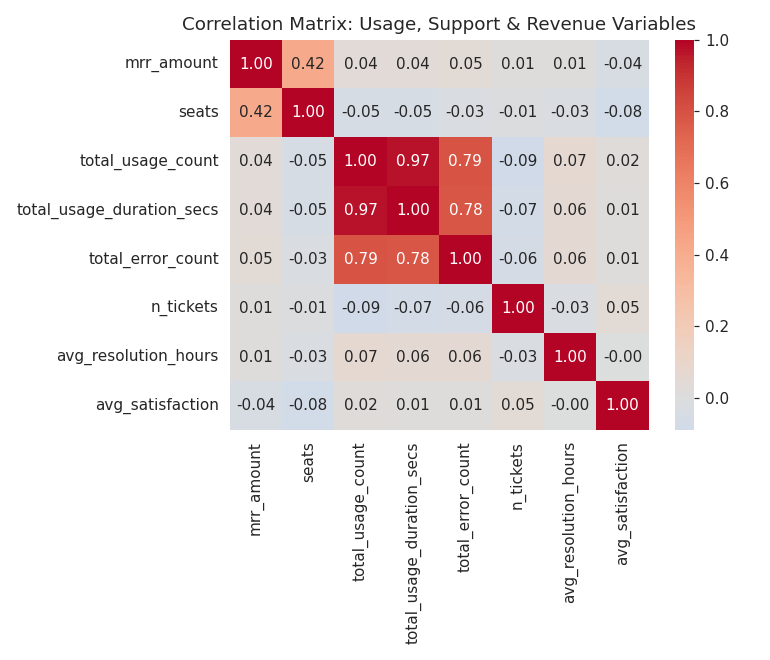

In [ ]:
corr_vars = ['mrr_amount','seats','total_usage_count','total_usage_duration_secs',             'total_error_count','n_tickets','avg_resolution_hours','avg_satisfaction']corr_matrix = master[corr_vars].dropna().corr(method='pearson').round(2)plt.figure(figsize=(7,6))sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')plt.title('Correlation Matrix: Usage, Support & Revenue Variables')plt.tight_layout()plt.show()

**Reading the heatmap:**
- `mrr_amount` and `seats` show a **moderate positive correlation (~0.42)** - larger accounts (more seats) tend to pay more, which makes sense for seat-based pricing.
- Usage variables (`total_usage_count`, `total_usage_duration_secs`, `total_error_count`) are only **weakly correlated with MRR** (below 0.1) - heavier product usage does not obviously translate into higher revenue in this dataset.
- Support variables (`n_tickets`, `avg_resolution_hours`, `avg_satisfaction`) show **very weak correlations** with everything else.

**Important limitation:** correlation only measures a linear association between two variables - it does **not** prove that one causes the other, and it can miss non-linear relationships. We only use these correlations to guide which hypotheses are worth testing next.

## 3. Hypothesis Testing

### Hypothesis 1: Product usage - churned vs retained
**Business question:** Do churned and retained customers differ in total product usage (total_usage_count)?

- **H0:** There is no significant difference in mean total usage between retained and churned customers.
- **H1:** There is a significant difference in mean total usage between retained and churned customers.
- **Test used:** Welch's Independent Samples t-test (two independent groups, unequal variances assumed)
- **Significance level (alpha):** 0.05

In [ ]:
retained_usage = master[master['status']=='Retained']['total_usage_count'].dropna()churned_usage  = master[master['status']=='Churned']['total_usage_count'].dropna()t_stat, p_value = stats.ttest_ind(retained_usage, churned_usage, equal_var=False)print(f"Retained mean usage: {retained_usage.mean():.2f}")print(f"Churned mean usage:  {churned_usage.mean():.2f}")print(f"t-statistic: {t_stat:.3f}")print(f"p-value: {p_value:.4f}")

Retained mean usage: 495.13Churned mean usage:  522.04t-statistic: -1.419p-value: 0.1578

**Conclusion:** With p = 0.1578 > 0.05, we **Fail to reject H0**. There is no statistically significant difference in total product usage between churned and retained customers in this dataset.

**Business meaning:** Usage volume alone does not appear to be a reliable early-warning signal for churn here - RavenStack should not assume "more usage = safer from churn" based on this data.

### Hypothesis 2: MRR across plan tiers
**Business question:** Do the three plan tiers (Basic, Pro, Enterprise) differ in average MRR?

- **H0:** The mean MRR is the same across all plan tiers.
- **H1:** At least one plan tier has a different mean MRR.
- **Test used:** One-Way ANOVA (3 independent groups)
- **Significance level (alpha):** 0.05

In [ ]:
groups = [master[master['current_plan_tier']==p]['mrr_amount'].dropna() for p in master['current_plan_tier'].dropna().unique()]f_stat, p_value = stats.f_oneway(*groups)print(master.groupby('current_plan_tier')['mrr_amount'].mean().round(2))print(f"\nF-statistic: {f_stat:.3f}")print(f"p-value: {p_value:.6f}")

current_plan_tierBasic          458.12Enterprise    5507.55Pro           1317.89Name: mrr_amount, dtype: float64F-statistic: 122.359p-value: 0.000000

**Conclusion:** p < 0.05, so we **Reject H0**. Average MRR is significantly different across plan tiers.

**Business meaning:** This is expected (plans are priced differently by design), but it's a good sanity check that pricing tiers are actually producing meaningfully different revenue outcomes, and it confirms Enterprise accounts are the primary revenue driver.

### Hypothesis 3: Support satisfaction - churned vs retained
**Business question:** Do churned customers report lower average support satisfaction scores than retained customers?

- **H0:** There is no significant difference in mean satisfaction score between retained and churned customers.
- **H1:** There is a significant difference in mean satisfaction score between retained and churned customers.
- **Test used:** Welch's Independent Samples t-test
- **Significance level (alpha):** 0.05

In [ ]:
retained_sat = master[master['status']=='Retained']['avg_satisfaction'].dropna()churned_sat  = master[master['status']=='Churned']['avg_satisfaction'].dropna()t_stat, p_value = stats.ttest_ind(retained_sat, churned_sat, equal_var=False)print(f"Retained mean satisfaction: {retained_sat.mean():.2f} (n={len(retained_sat)})")print(f"Churned mean satisfaction:  {churned_sat.mean():.2f} (n={len(churned_sat)})")print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

Retained mean satisfaction: 3.95 (n=364)Churned mean satisfaction:  4.00 (n=102)t-statistic: -0.779, p-value: 0.4373

**Conclusion:** p = 0.4373 > 0.05, so we **Fail to reject H0**. Support satisfaction scores do not differ significantly between churned and retained customers in this dataset.

**Business meaning:** We should be cautious about assuming poor support satisfaction is a major, dataset-wide churn driver - at least not on this simple average comparison. It's still worth investigating specific low-satisfaction segments qualitatively (see churn feedback text).

### Bonus check: Is churn associated with plan tier? (Chi-square test)
- **H0:** Churn status is independent of plan tier.
- **H1:** Churn status is associated with plan tier.
- **Test used:** Chi-square test of independence
- **Chi-square statistic:** 0.477, **dof:** 2, **p-value:** 0.7879
- **Conclusion:** Fail to reject H0 - churn does not appear to be associated with plan tier in this dataset.

## 4. Hypothetical A/B Test (illustrative example only)

> **This is a hypothetical, simulated example.** RavenStack's dataset does **not** contain a real A/B experiment. This section shows how RavenStack *could* design and analyze a future onboarding test, using simulated numbers that are clearly separated from the real analysis above.

**Scenario:** "RavenStack wants to test whether a new onboarding checklist improves product activation (measured as: did the account use at least 3 different features in its first 14 days?)."

- **Control:** existing onboarding flow
- **Treatment:** new onboarding checklist
- **Primary metric:** activation rate (% of new accounts activated within 14 days)
- **H0:** Activation rate is the same for control and treatment.
- **H1:** Activation rate is higher for the treatment group.
- **Test:** two-proportion z-test

In [ ]:
# SIMULATED data for illustration only - not derived from RavenStack's real datasetnp.random.seed(42)control_n, treatment_n = 250, 250control_activated = 92     # simulated: 36.8% activationtreatment_activated = 115  # simulated: 46.0% activationp_control = control_activated / control_np_treatment = treatment_activated / treatment_np_pool = (control_activated + treatment_activated) / (control_n + treatment_n)se = np.sqrt(p_pool * (1 - p_pool) * (1/control_n + 1/treatment_n))z = (p_treatment - p_control) / sep_value = 1 - stats.norm.cdf(z)  # one-sided test (treatment > control)print(f"Control activation rate:   {p_control:.1%}")print(f"Treatment activation rate: {p_treatment:.1%}")print(f"z-statistic: {z:.2f}")print(f"p-value (one-sided): {p_value:.4f}")

Control activation rate:   36.8%Treatment activation rate: 46.0%z-statistic: 2.16p-value (one-sided): 0.0154

**Interpretation (simulated result):** With p ≈ 0.015 < 0.05, we would reject H0 in this simulated example and conclude the new onboarding checklist significantly increases activation. **Again: these numbers are simulated for teaching purposes and are not a real RavenStack result.** Before rolling this out, RavenStack would want a properly randomized, pre-registered experiment with a larger sample and a fixed test duration.

## 5. Regression Fundamentals

**Business question:** Can customer usage help explain differences in MRR?

- **Dependent variable (Y):** `mrr_amount`
- **Independent variable (X):** `total_usage_count`

In [ ]:
df = master[['mrr_amount','total_usage_count']].dropna()slope, intercept, r_value, p_value, std_err = stats.linregress(df['total_usage_count'], df['mrr_amount'])print(f"n = {len(df)}")print(f"Slope: {slope:.4f}")print(f"Intercept: {intercept:.2f}")print(f"R-squared: {r_value**2:.4f}")print(f"p-value: {p_value:.4f}")

n = 500Slope: 0.9676Intercept: 2030.97R-squared: 0.0019p-value: 0.3346

**Interpretation:** R² = 0.0019 means `total_usage_count` explains less than 1% of the variation in MRR, and the relationship is **not statistically significant** (p = 0.3346 > 0.05). Usage alone is a poor predictor of MRR in this dataset.

Since seats are also in the data and are a natural driver of seat-based pricing, let's check that relationship too.

Slope: 79.73  (each extra seat is associated with ~$80 more MRR)R-squared: 0.1861p-value: 0.000000

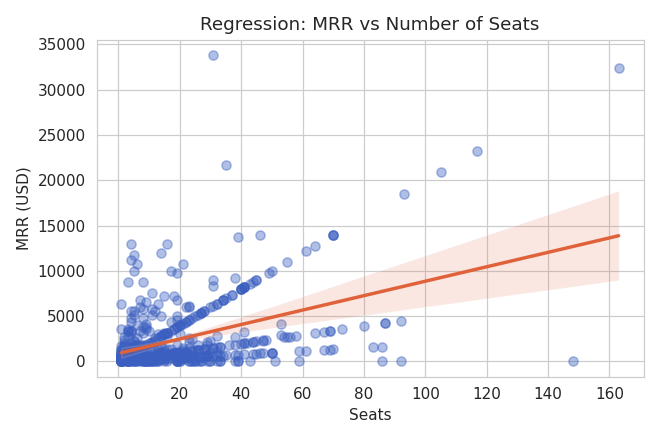

In [ ]:
df2 = master[['mrr_amount','seats']].dropna()slope2, intercept2, r2, p2, se2 = stats.linregress(df2['seats'], df2['mrr_amount'])print(f"Slope: {slope2:.2f}  (each extra seat is associated with ~${slope2:.0f} more MRR)")print(f"R-squared: {r2**2:.4f}")print(f"p-value: {p2:.6f}")plt.figure(figsize=(6,4))sns.regplot(data=master, x='seats', y='mrr_amount', scatter_kws={'alpha':0.4,'color':'#3b5fc0'}, line_kws={'color':'#e0623a'})plt.title('Regression: MRR vs Number of Seats')plt.tight_layout()plt.show()

**Interpretation:** `seats` explains about 18.6% of the variance in MRR (R² = 0.1861), and the relationship is statistically significant (p < 0.001). This is a much stronger, more intuitive relationship than usage: bigger accounts (more seats) pay more.

**Limitations of this regression:** it is a simple one-variable (bivariate) linear regression - it does not control for plan tier, industry, or other factors at the same time, and R² of ~0.19 still leaves most of the variation in MRR unexplained. This is regression *fundamentals*, not a production pricing model.

## Summary of Notebook 2
- Churned and retained customers do **not** differ significantly in usage or satisfaction (both hypothesis tests failed to reject H0).
- MRR **does** differ significantly by plan tier (as expected by design).
- Churn is **not** significantly associated with plan tier (chi-square test).
- A hypothetical, clearly-simulated A/B test example shows how RavenStack could evaluate a future onboarding experiment.
- A simple regression shows usage barely predicts MRR, while number of seats is a much stronger (though still partial) predictor.